# VNU-LEO Constellation Simulation

**Module**: `orbit_calc/simulation.ipynb`  
**Purpose**: Visualize satellite ground tracks, coverage footprints, handover zones, and revisit timeline for Vietnam ground stations.

## Contents
1. Setup & imports
2. Constellation parameters
3. Ground track simulation (24 hours)
4. Coverage footprint map (Vietnam)
5. Handover zone visualization
6. Revisit timeline per station
7. Elevation angle time series
8. Export results (CSV, JSON, TLE)

## 1. Setup & Imports

In [1]:
import sys
import os
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import Circle
from pathlib import Path

# Add parent directory to path so we can import our modules
sys.path.insert(0, str(Path('.').resolve()))

from coverage_calculator import (
    WalkerDelta, VietnamCoverageAnalyzer,
    walker_delta_positions, elevation_angle_deg,
    coverage_half_angle_rad, footprint_radius_km,
    estimate_minimum_satellites,
    VIETNAM_STATIONS, RE_KM, MU_KM3S2,
)
from traffic_model import (
    TrafficModel, INTERNET_VOIP_PROFILE, DATA_WEATHER_PROFILE,
    dwell_time_s, slant_range_from_elevation,
)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'text.color': '#e6edf3',
    'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'grid.linewidth': 0.5,
    'legend.facecolor': '#21262d',
    'legend.edgecolor': '#30363d',
})

OUTPUT_DIR = Path('outputs/simulation')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Imports OK')

✅ Imports OK


## 2. Constellation Parameters

Define Walker Delta constellations for both service profiles.  
Analytical minimum satellite estimates are printed below.

In [2]:
# ── Recommended constellations ──────────────────────────────────────────
CONSTELLATIONS = {
    'internet': WalkerDelta(N=24, P=6, F=1, inclination_deg=53.0, altitude_km=500.0),
    'weather':  WalkerDelta(N=18, P=6, F=1, inclination_deg=53.0, altitude_km=1000.0),
}

# ── Analytical estimates ─────────────────────────────────────────────────
print('Analytical minimum satellite estimates:')
print('-' * 60)
for label, h in [('Internet/VoIP (500 km)', 500), ('Data/Weather (1000 km)', 1000)]:
    est = estimate_minimum_satellites(h, el_min_deg=15.0, inclination_deg=53.0)
    print(f'\n{label}:')
    for k, v in est.items():
        print(f'  {k:<28} = {v}')

print('\n\nSelected Walker Delta configurations:')
for svc, c in CONSTELLATIONS.items():
    print(f'  {svc}: {c}  → {c.satellites_per_plane} sats/plane, '
          f'T={c.orbital_period_min:.1f}min, v={c.orbital_velocity_km_s:.2f}km/s')

Analytical minimum satellite estimates:
------------------------------------------------------------

Internet/VoIP (500 km):
  N                            = 306
  P                            = 17
  Ns                           = 18
  F                            = 0
  rho_deg                      = 11.41
  rho_km                       = 1268.7
  T_orbit_min                  = 94.47
  T_revisit_min                = 87.67
  footprint_diameter_km        = 2537.4

Data/Weather (1000 km):
  N                            = 110
  P                            = 10
  Ns                           = 11
  F                            = 0
  rho_deg                      = 18.396
  rho_km                       = 2045.6
  T_orbit_min                  = 104.97
  T_revisit_min                = 102.7
  footprint_diameter_km        = 4091.2


Selected Walker Delta configurations:
  internet: Walker Delta 24/6/1 i=53.0° h=500.0km  → 4 sats/plane, T=94.5min, v=7.62km/s
  weather: Walker Delta 18/6/1 i=53.

## 3. Ground Track Simulation (24 hours)

Plotting ground tracks...
  Saved: outputs\simulation\ground_tracks_internet.png


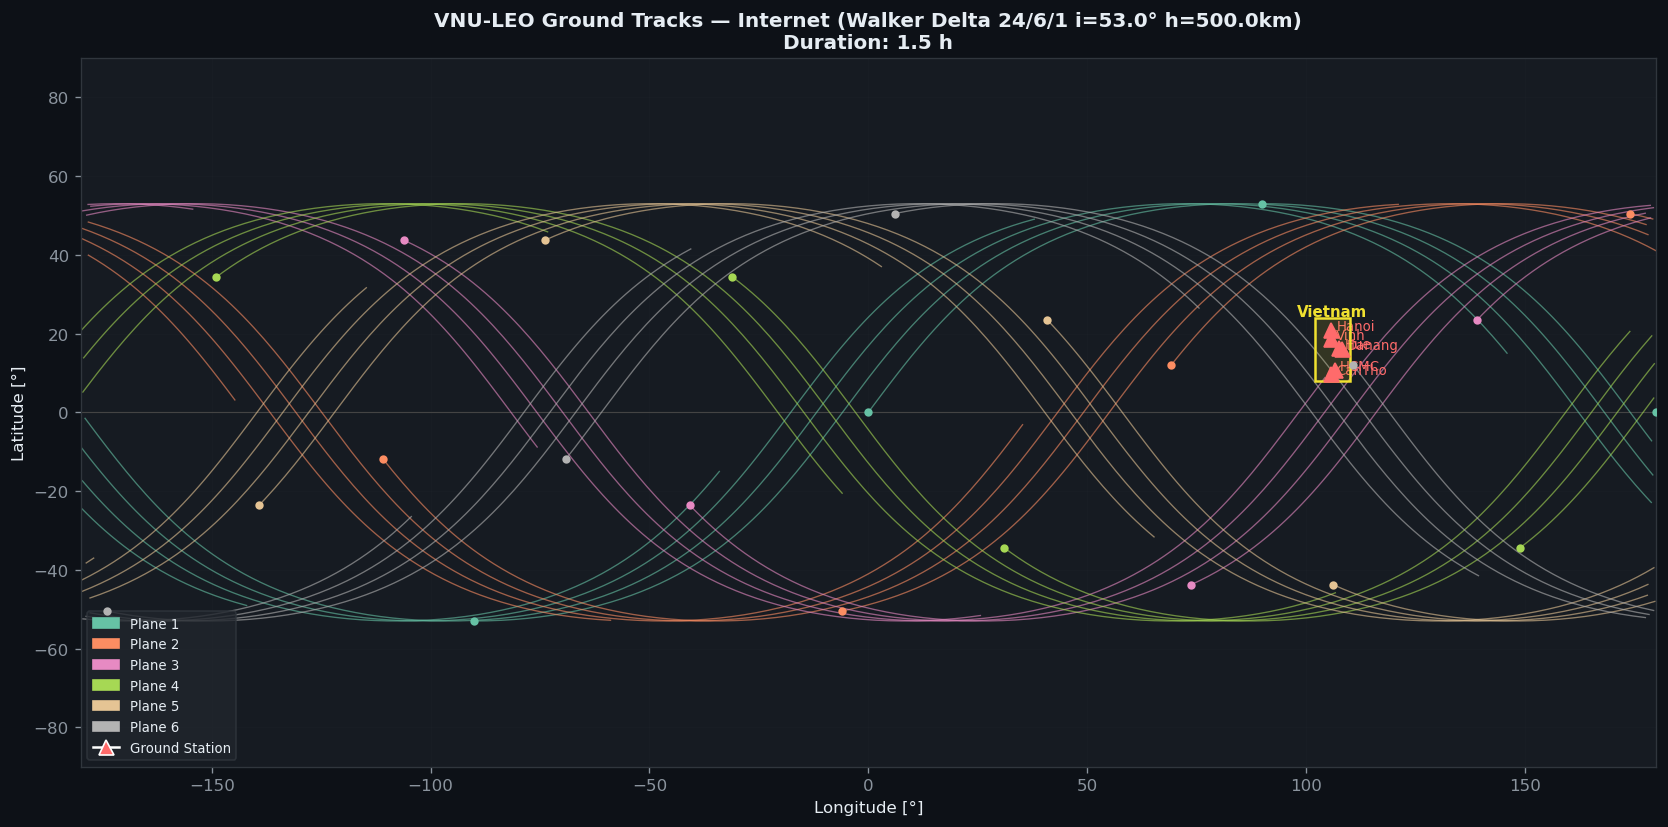

  Saved: outputs\simulation\ground_tracks_weather.png


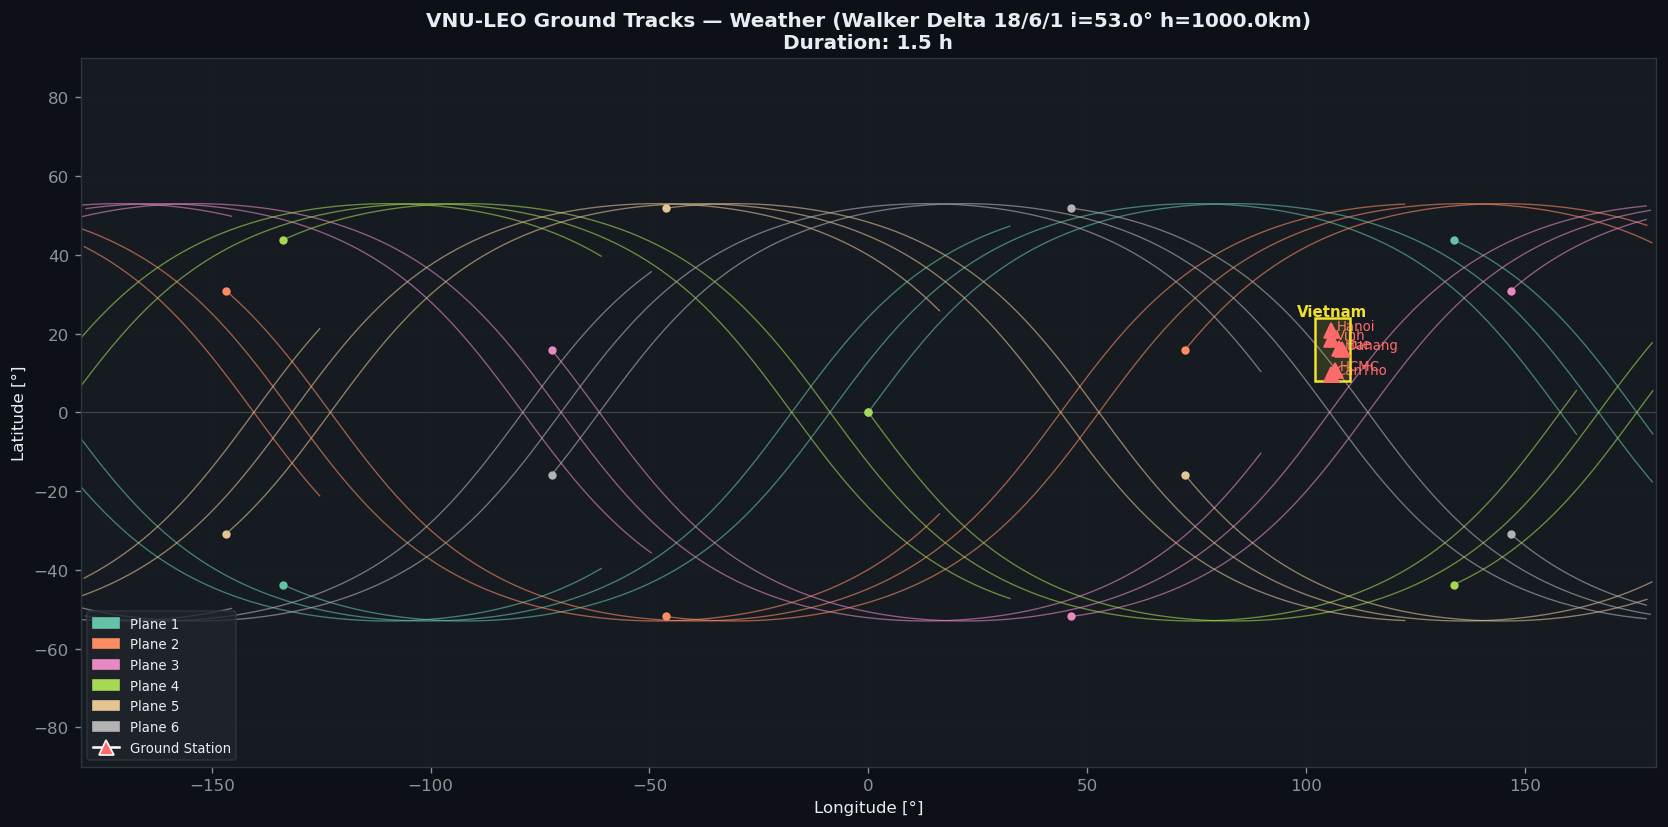

In [3]:
def compute_ground_tracks(constellation: WalkerDelta,
                           duration_s: float = 86400.0,
                           step_s: float = 30.0) -> list[list[tuple[float, float]]]:
    """Return list of (lat, lon) time series for each satellite."""
    times = np.arange(0, duration_s, step_s)
    N = constellation.N
    tracks = [[] for _ in range(N)]
    for t in times:
        positions = walker_delta_positions(constellation, t)
        for i, (lat, lon) in enumerate(positions):
            tracks[i].append((lat, lon))
    return tracks


def plot_ground_tracks(constellation: WalkerDelta, service_label: str,
                        duration_s: float = 5400.0) -> None:
    """Plot ground tracks on a world map."""
    tracks = compute_ground_tracks(constellation, duration_s, step_s=30.0)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.set_xlabel('Longitude [°]')
    ax.set_ylabel('Latitude [°]')
    ax.set_title(f'VNU-LEO Ground Tracks — {service_label} ({constellation})\n'
                 f'Duration: {duration_s/3600:.1f} h', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='#444', linewidth=0.7)
    
    # Vietnam bounding box
    from matplotlib.patches import Rectangle
    vn_box = Rectangle((102, 8), 8, 16, linewidth=1.5,
                         edgecolor='#f0e130', facecolor='#f0e13022', zorder=5)
    ax.add_patch(vn_box)
    ax.text(106, 24.5, 'Vietnam', color='#f0e130', fontsize=9,
            ha='center', fontweight='bold')
    
    # Plot satellite tracks by plane
    colors = plt.cm.Set2(np.linspace(0, 1, constellation.P))
    Ns = constellation.satellites_per_plane
    
    for i, track in enumerate(tracks):
        plane_idx = i // Ns
        lats = [p[0] for p in track]
        lons = [p[1] for p in track]
        # Handle longitude wrap-around
        segments_lat, segments_lon = [], []
        seg_lat, seg_lon = [lats[0]], [lons[0]]
        for j in range(1, len(lons)):
            if abs(lons[j] - lons[j-1]) > 180:
                segments_lat.append(seg_lat)
                segments_lon.append(seg_lon)
                seg_lat, seg_lon = [lats[j]], [lons[j]]
            else:
                seg_lat.append(lats[j])
                seg_lon.append(lons[j])
        segments_lat.append(seg_lat)
        segments_lon.append(seg_lon)
        for sl, so in zip(segments_lat, segments_lon):
            ax.plot(so, sl, '-', color=colors[plane_idx], alpha=0.6, linewidth=0.8)
        # Mark initial position
        ax.plot(lons[0], lats[0], 'o', color=colors[plane_idx],
                markersize=4, zorder=10)
    
    # Ground stations
    for name, (lat, lon) in VIETNAM_STATIONS.items():
        ax.plot(lon, lat, '^', color='#ff6b6b', markersize=9, zorder=15)
        ax.text(lon + 1.2, lat, name, color='#ff6b6b', fontsize=8)
    
    # Legend for planes
    handles = [mpatches.Patch(color=colors[p], label=f'Plane {p+1}')
               for p in range(constellation.P)]
    handles.append(plt.Line2D([0],[0], marker='^', color='w',
                               markerfacecolor='#ff6b6b', markersize=9,
                               label='Ground Station'))
    ax.legend(handles=handles, loc='lower left', fontsize=8)
    
    plt.tight_layout()
    fname = OUTPUT_DIR / f'ground_tracks_{service_label.lower().replace("/","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    print(f'  Saved: {fname}')
    plt.show()


print('Plotting ground tracks...')
for svc, c in CONSTELLATIONS.items():
    plot_ground_tracks(c, service_label=svc.capitalize(), duration_s=5400.0)

## 4. Coverage Footprint Map — Vietnam

  Saved: outputs\simulation\coverage_footprint_internet.png


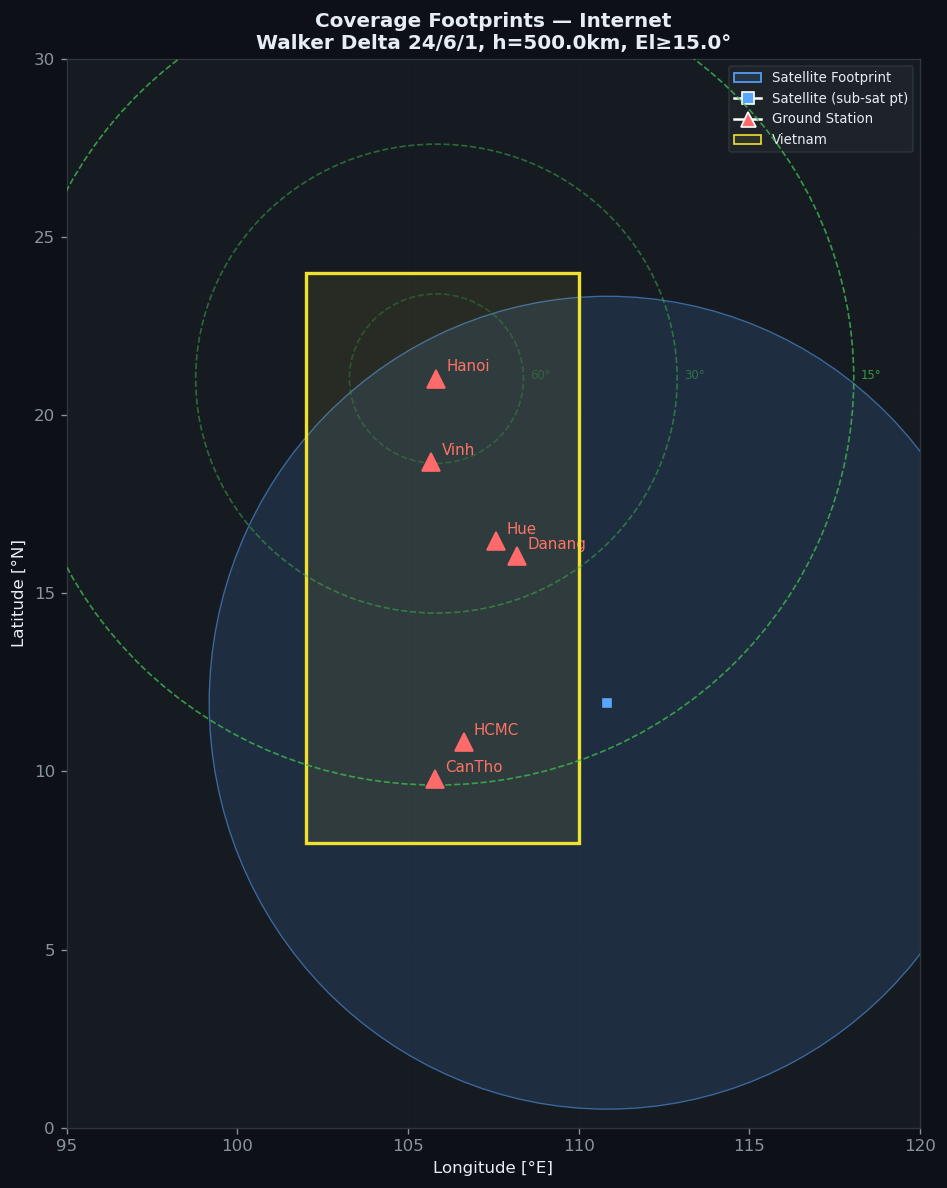

  Saved: outputs\simulation\coverage_footprint_weather.png


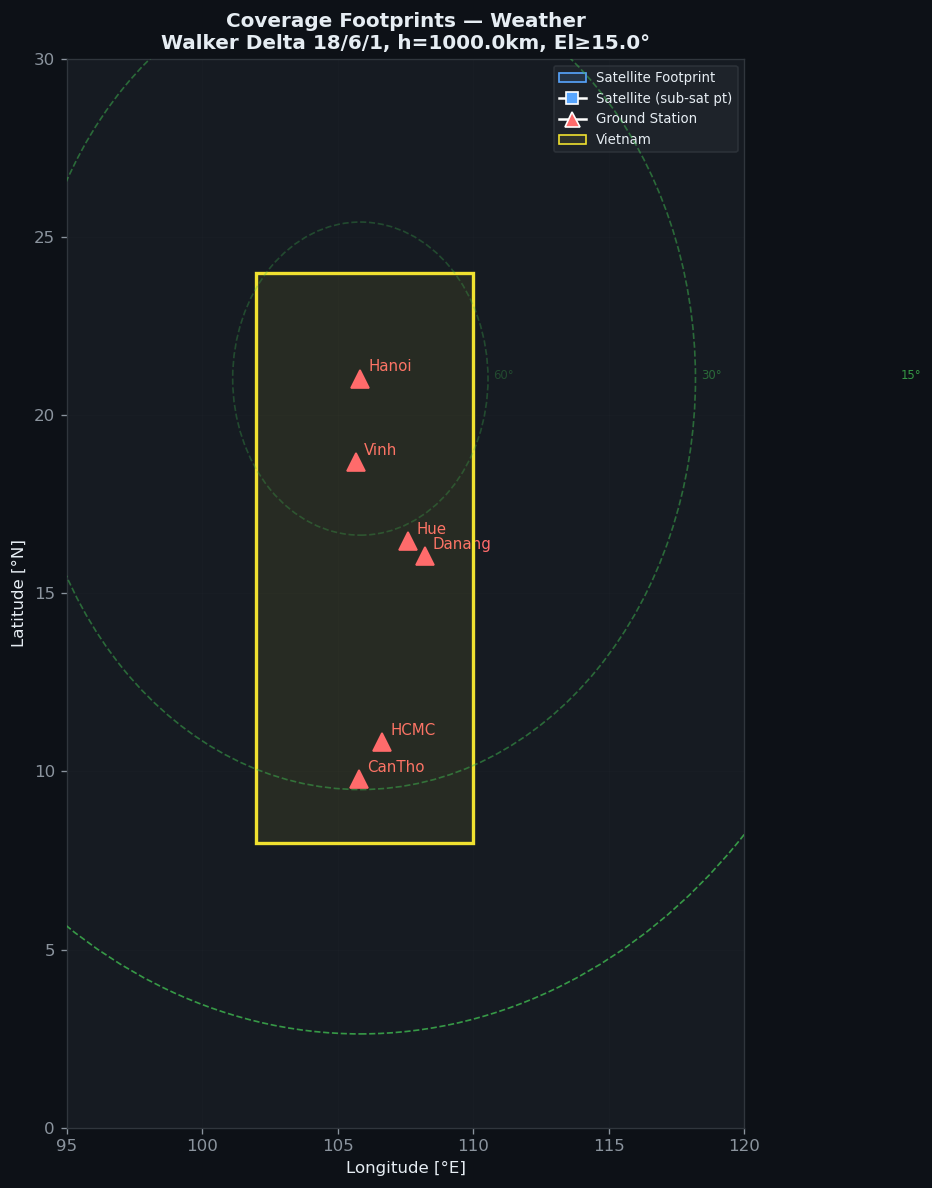

In [4]:
def plot_coverage_footprint(constellation: WalkerDelta, service_label: str,
                              el_min_deg: float = 15.0, t_s: float = 0.0) -> None:
    """Show satellite footprints over Vietnam at a single epoch."""
    rho_deg = math.degrees(coverage_half_angle_rad(constellation.altitude_km, el_min_deg))
    positions = walker_delta_positions(constellation, t_s)
    
    # Filter to satellites near Vietnam (within 3*rho of Vietnam centroid)
    vn_lat, vn_lon = 16.0, 106.0
    nearby = [(lat, lon) for lat, lon in positions
               if abs(lat - vn_lat) < 3*rho_deg and abs(lon - vn_lon) < 3*rho_deg]
    
    fig, ax = plt.subplots(figsize=(8, 10))
    ax.set_xlim(95, 120)
    ax.set_ylim(0, 30)
    ax.set_xlabel('Longitude [°E]')
    ax.set_ylabel('Latitude [°N]')
    ax.set_title(f'Coverage Footprints — {service_label}\n'
                 f'Walker Delta {constellation.N}/{constellation.P}/{constellation.F}, '
                 f'h={constellation.altitude_km}km, El≥{el_min_deg}°', fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Vietnam bounding box
    from matplotlib.patches import Rectangle, Ellipse
    vn_box = Rectangle((102, 8), 8, 16, linewidth=2,
                         edgecolor='#f0e130', facecolor='#f0e13015', zorder=5, label='Vietnam')
    ax.add_patch(vn_box)
    
    # Draw footprint circles (approximate as ellipse on lat/lon plot)
    for j, (sat_lat, sat_lon) in enumerate(positions):
        # Check if footprint overlaps Vietnam view
        if (sat_lat < -2*rho_deg or sat_lat > 30 + 2*rho_deg or
                sat_lon < 90 or sat_lon > 125):
            continue
        
        # Footprint: circle in degrees (lon is stretched at lower latitudes)
        # Approximate as ellipse: a=rho_deg/cos(lat), b=rho_deg in lat
        cos_lat = math.cos(math.radians(sat_lat)) or 1e-3
        circle = mpatches.Ellipse(
            (sat_lon, sat_lat),
            width=2 * rho_deg / cos_lat,
            height=2 * rho_deg,
            fill=True, facecolor='#58a6ff22', edgecolor='#58a6ff88',
            linewidth=0.8, zorder=3,
        )
        ax.add_patch(circle)
        ax.plot(sat_lon, sat_lat, 's', color='#58a6ff', markersize=5, zorder=10)
    
    # Ground stations
    for name, (lat, lon) in VIETNAM_STATIONS.items():
        ax.plot(lon, lat, '^', color='#ff6b6b', markersize=11, zorder=15)
        ax.text(lon + 0.3, lat + 0.2, name, color='#ff6b6b', fontsize=9)
    
    # Elevation contours (example: concentric rings around Hanoi)
    hn_lat, hn_lon = VIETNAM_STATIONS['Hanoi']
    for el_contour, alpha in [(15, 0.8), (30, 0.5), (60, 0.3)]:
        rho_c = math.degrees(coverage_half_angle_rad(constellation.altitude_km, el_contour))
        cos_lat = math.cos(math.radians(hn_lat))
        circle_c = mpatches.Ellipse(
            (hn_lon, hn_lat),
            width=2*rho_c/cos_lat, height=2*rho_c,
            fill=False, edgecolor='#3fb950', linewidth=1.0,
            linestyle='--', zorder=6, alpha=alpha,
        )
        ax.add_patch(circle_c)
        ax.text(hn_lon + rho_c/cos_lat + 0.2, hn_lat,
                f'{el_contour}°', color='#3fb950', fontsize=7, alpha=alpha)
    
    handles = [
        mpatches.Patch(facecolor='#58a6ff22', edgecolor='#58a6ff', label='Satellite Footprint'),
        plt.Line2D([0],[0], marker='s', color='w',
                    markerfacecolor='#58a6ff', markersize=7, label='Satellite (sub-sat pt)'),
        plt.Line2D([0],[0], marker='^', color='w',
                    markerfacecolor='#ff6b6b', markersize=9, label='Ground Station'),
        mpatches.Patch(facecolor='#f0e13015', edgecolor='#f0e130', label='Vietnam'),
    ]
    ax.legend(handles=handles, loc='upper right', fontsize=8)
    
    plt.tight_layout()
    fname = OUTPUT_DIR / f'coverage_footprint_{service_label.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    print(f'  Saved: {fname}')
    plt.show()


for svc, c in CONSTELLATIONS.items():
    plot_coverage_footprint(c, service_label=svc.capitalize())

## 5. Handover Zone Visualization


INTERNET — Hanoi
  Saved: outputs\simulation\handover_zones_hanoi_internet.png
  Handover events in 2.0h: 5
  Mean handover interval: 23.6 min


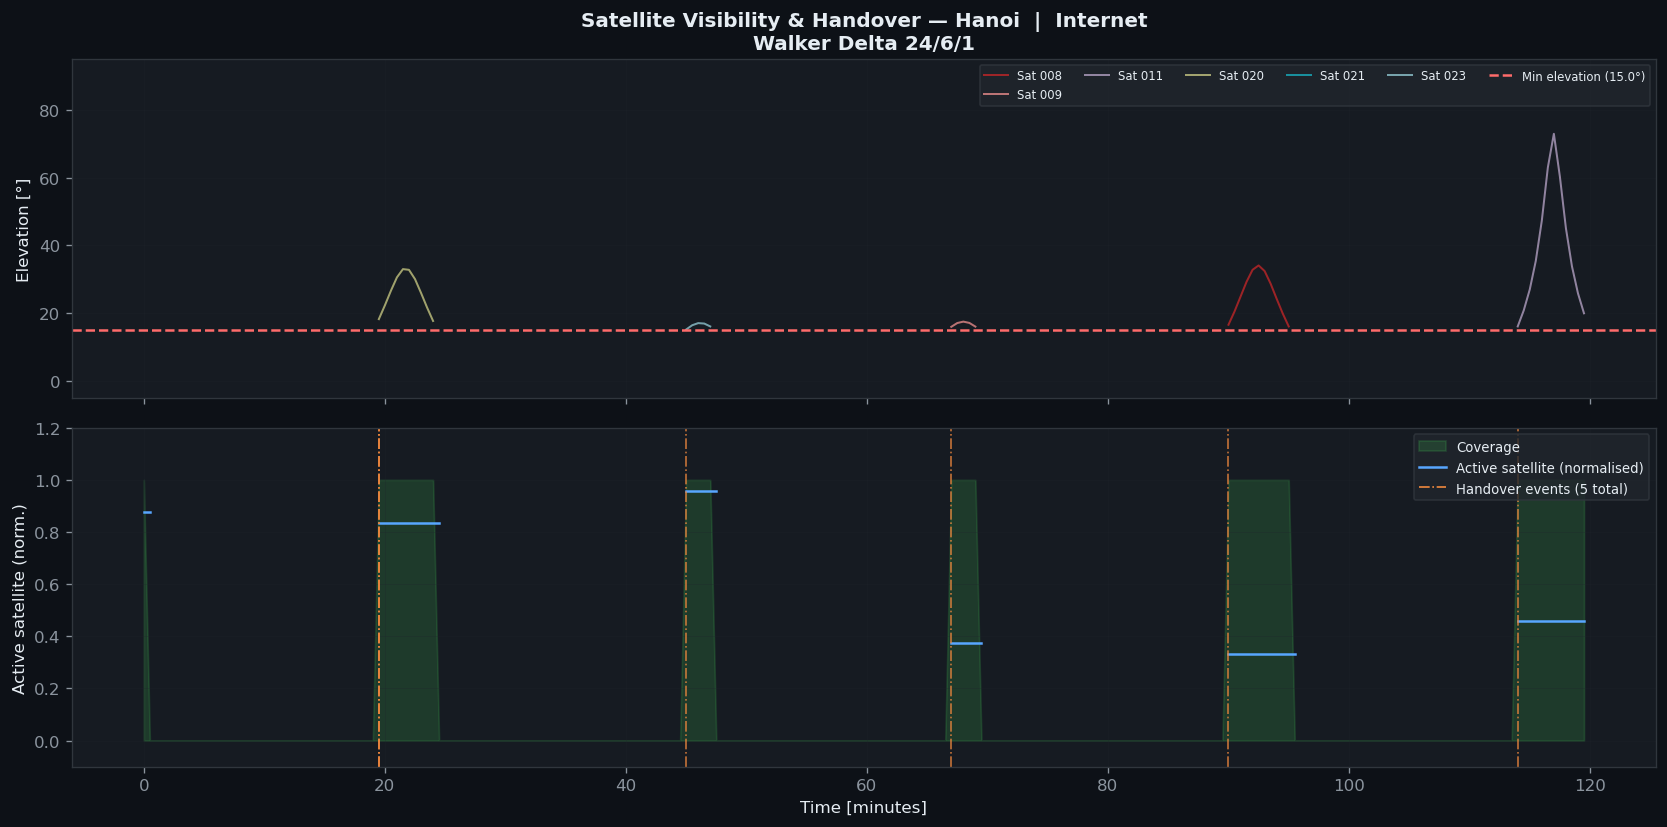


INTERNET — Danang
  Saved: outputs\simulation\handover_zones_danang_internet.png
  Handover events in 2.0h: 6
  Mean handover interval: 18.6 min


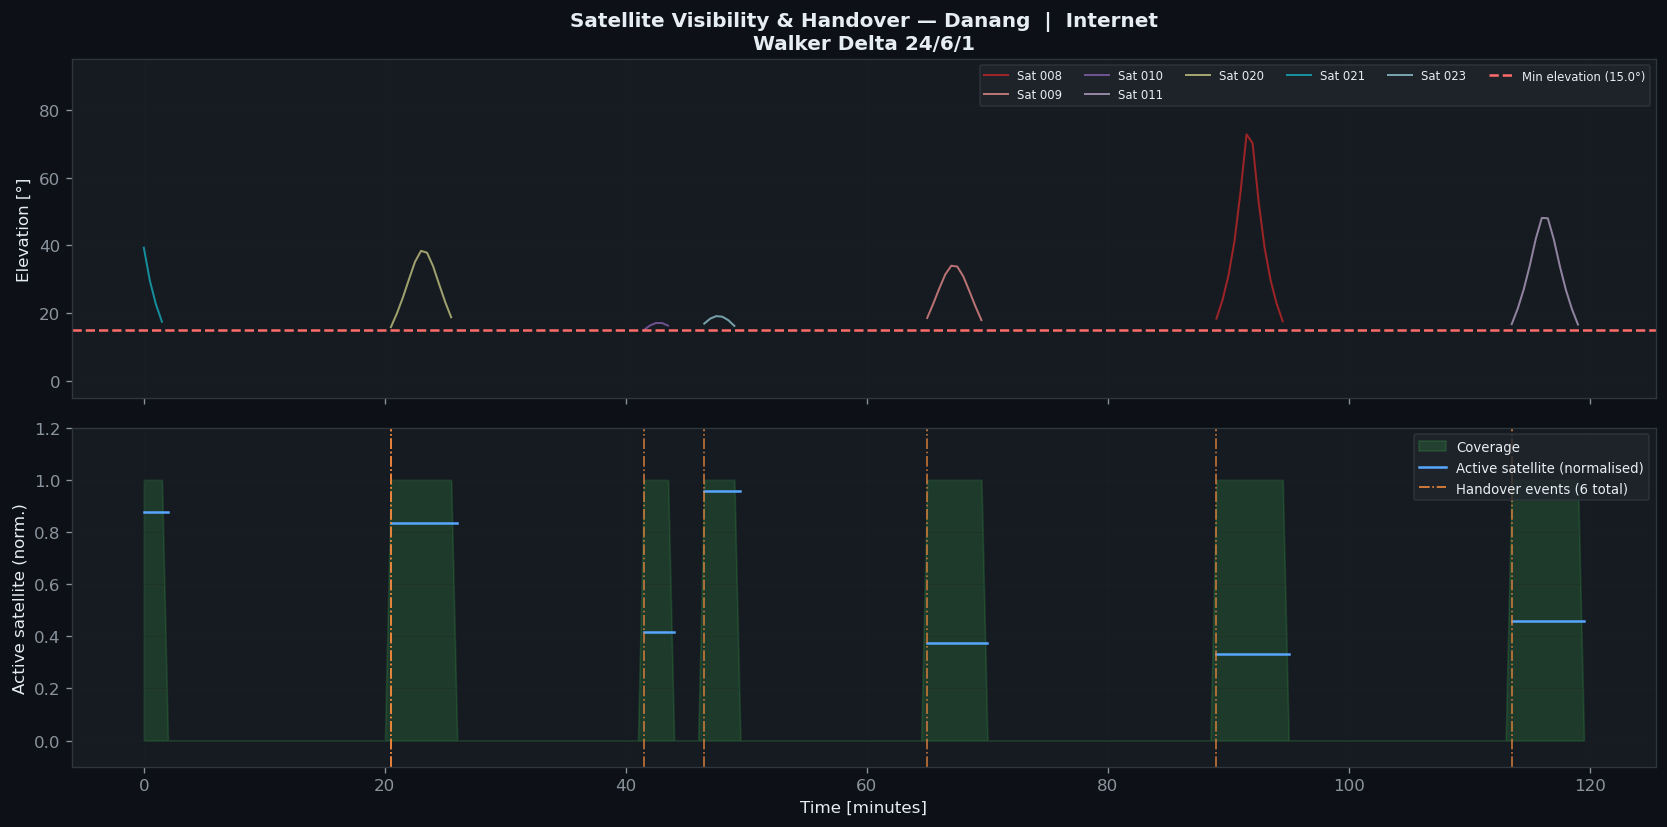


INTERNET — HCMC
  Saved: outputs\simulation\handover_zones_hcmc_internet.png
  Handover events in 2.0h: 7
  Mean handover interval: 15.2 min


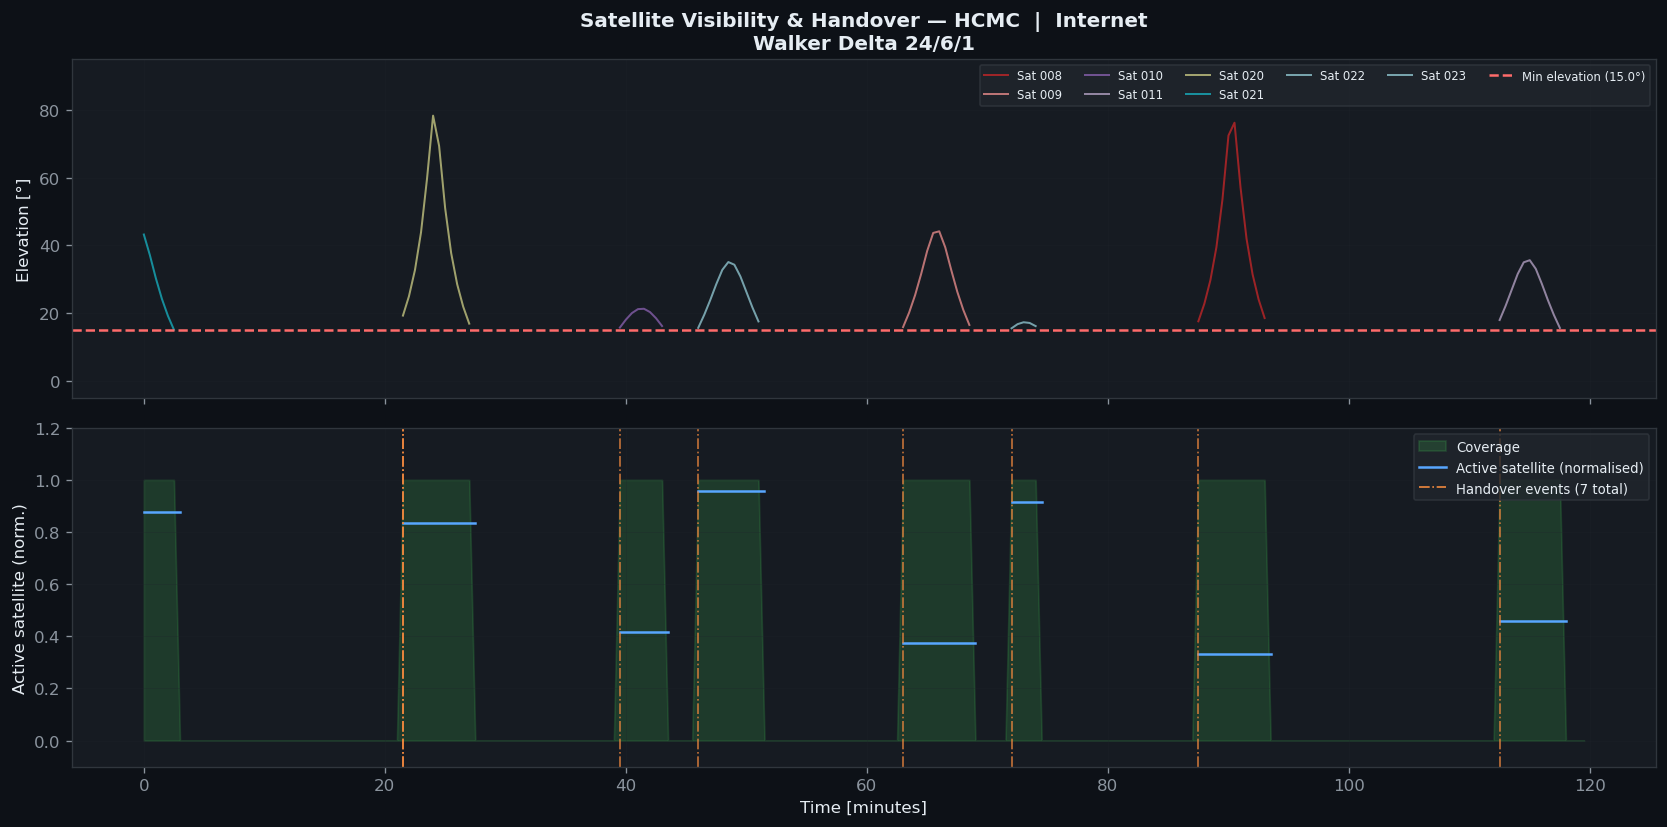


WEATHER — Hanoi
  Saved: outputs\simulation\handover_zones_hanoi_weather.png
  Handover events in 2.0h: 4
  Mean handover interval: 22.7 min


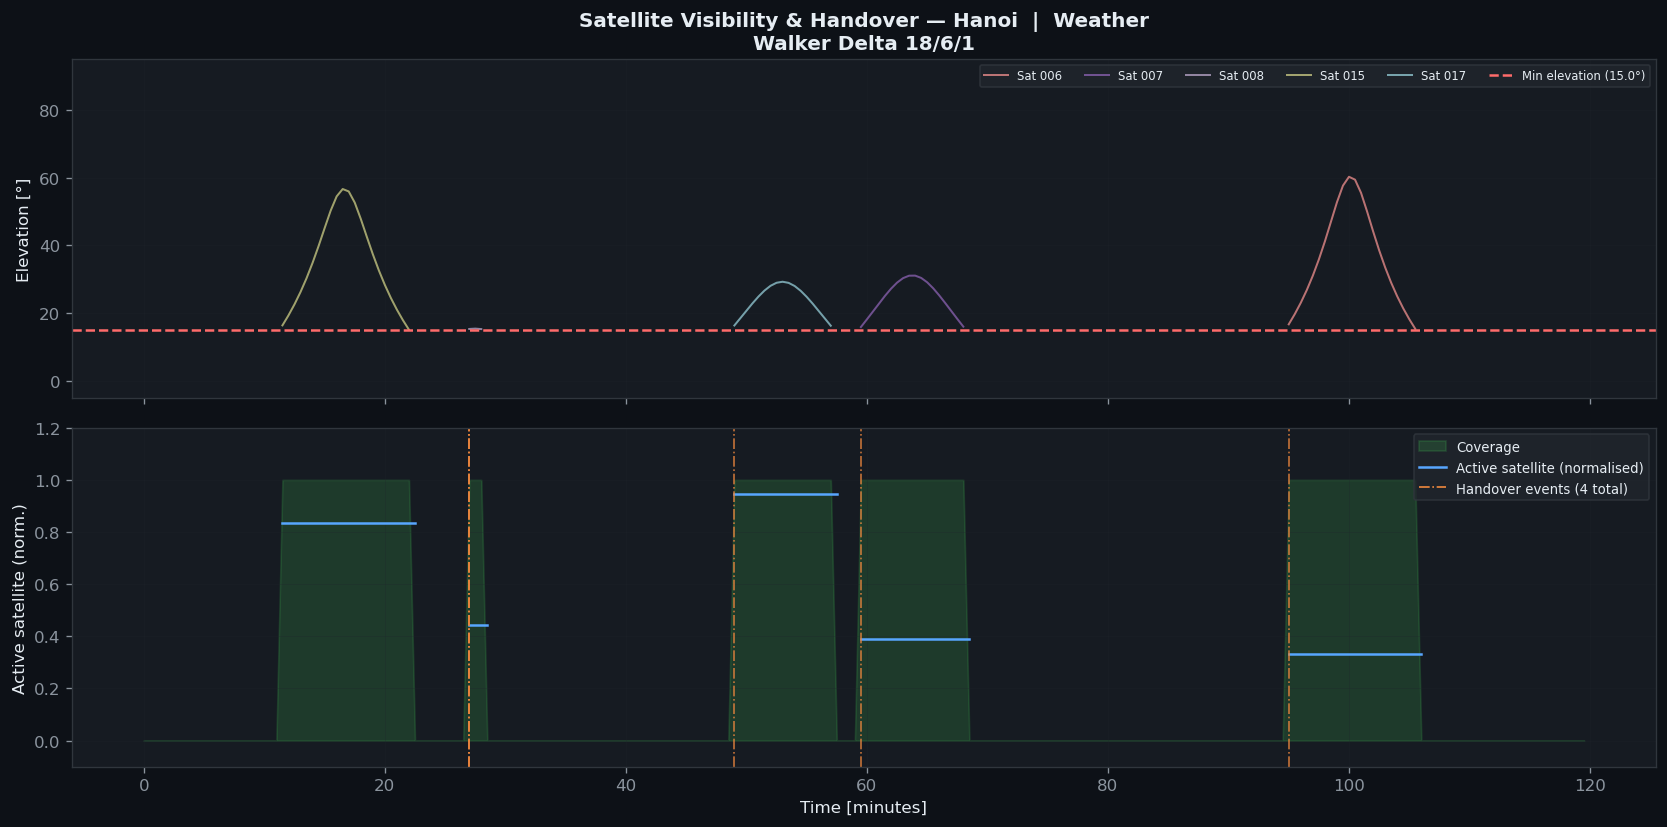


WEATHER — Danang
  Saved: outputs\simulation\handover_zones_danang_weather.png
  Handover events in 2.0h: 5
  Mean handover interval: 17.6 min


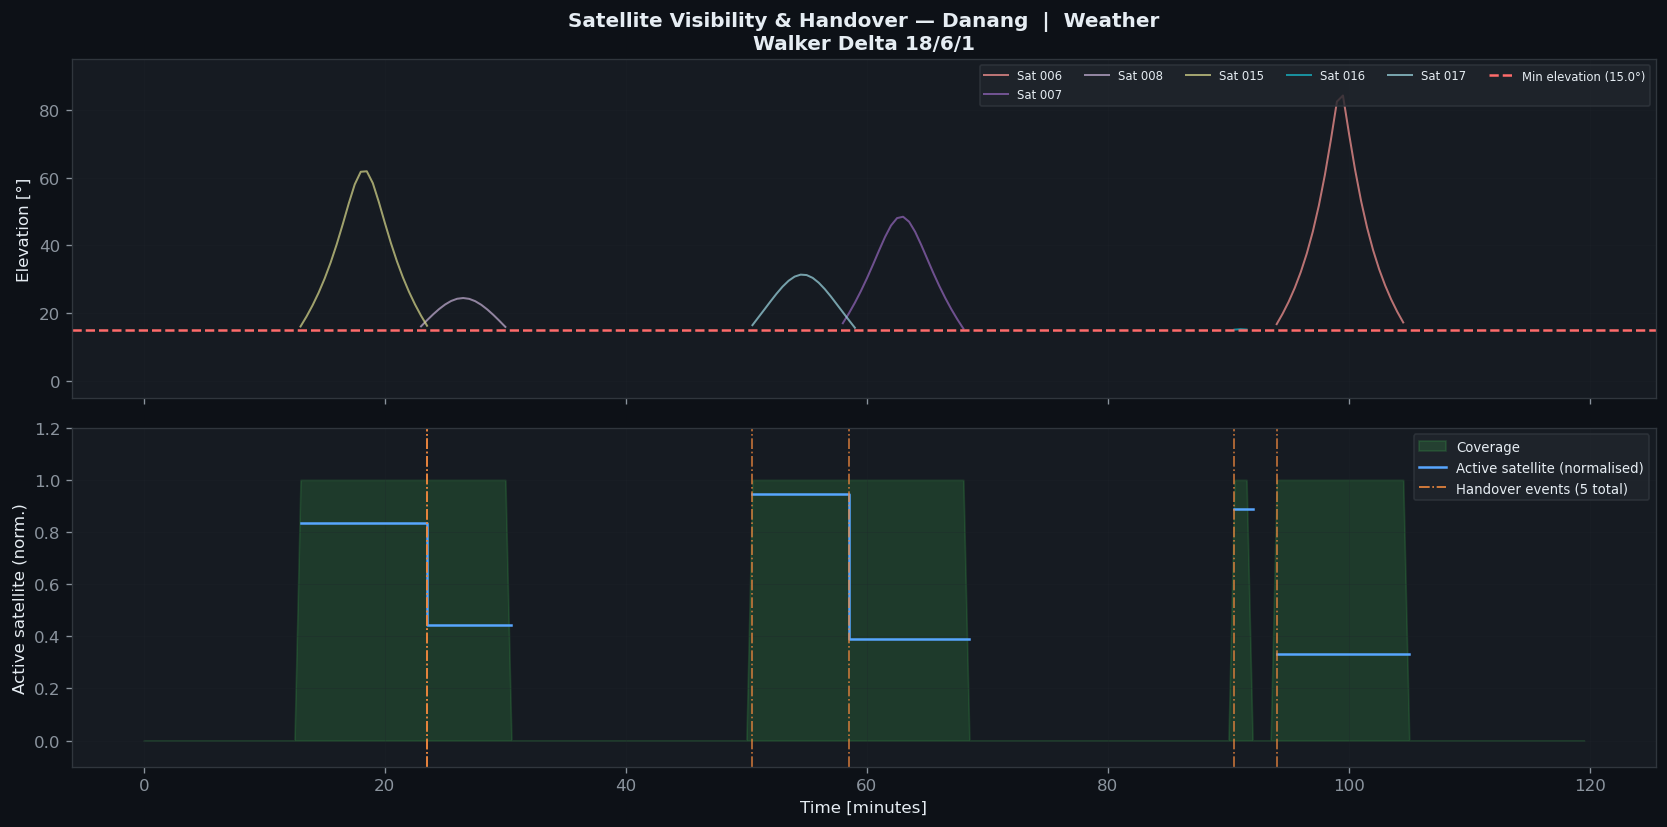


WEATHER — HCMC
  Saved: outputs\simulation\handover_zones_hcmc_weather.png
  Handover events in 2.0h: 5
  Mean handover interval: 17.5 min


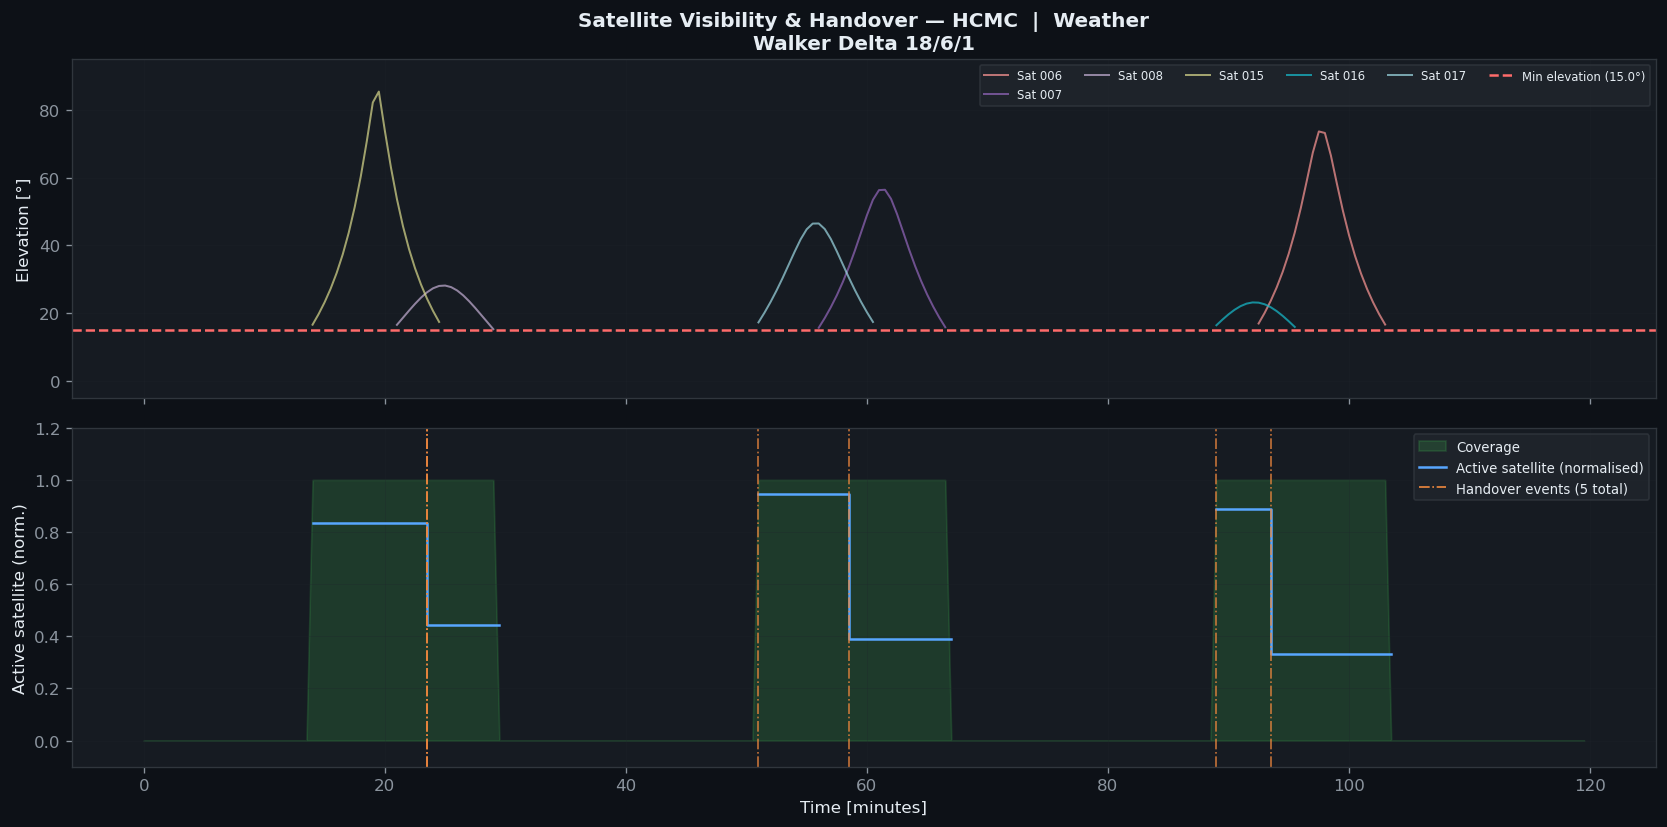

In [5]:
def plot_handover_zones(constellation: WalkerDelta, service_label: str,
                         station_name: str = 'Hanoi',
                         el_min_deg: float = 15.0,
                         sim_duration_s: float = 7200.0) -> None:
    """Show elevation angle time series and mark handover events."""
    gs_lat, gs_lon = VIETNAM_STATIONS[station_name]
    times = np.arange(0, sim_duration_s, 30.0)
    h = constellation.altitude_km
    
    # Per-satellite elevation over time
    el_series = np.full((constellation.N, len(times)), -90.0)
    for step_idx, t in enumerate(times):
        positions = walker_delta_positions(constellation, t)
        for sat_idx, (sat_lat, sat_lon) in enumerate(positions):
            el_series[sat_idx, step_idx] = elevation_angle_deg(
                sat_lat, sat_lon, h, gs_lat, gs_lon)
    
    # Max elevation at each timestep
    max_el = np.max(el_series, axis=0)
    best_sat = np.argmax(el_series, axis=0)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    
    # Top: elevation time series for visible satellites
    t_min = times / 60.0
    colors_sat = plt.cm.tab20(np.linspace(0, 1, constellation.N))
    
    for sat_idx in range(constellation.N):
        el = el_series[sat_idx]
        visible = el >= el_min_deg
        if not np.any(visible):
            continue
        el_plot = np.where(visible, el, np.nan)
        ax1.plot(t_min, el_plot, '-', color=colors_sat[sat_idx],
                  alpha=0.7, linewidth=1.2,
                  label=f'Sat {sat_idx:03d}')
    
    ax1.axhline(el_min_deg, color='#ff6b6b', linewidth=1.5,
                linestyle='--', label=f'Min elevation ({el_min_deg}°)')
    ax1.set_ylabel('Elevation [°]')
    ax1.set_ylim(-5, 95)
    ax1.set_title(f'Satellite Visibility & Handover — {station_name}  |  {service_label}\n'
                   f'Walker Delta {constellation.N}/{constellation.P}/{constellation.F}',
                   fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=7, ncol=6, loc='upper right')
    
    # Bottom: active satellite (handover events)
    covered = max_el >= el_min_deg
    active_sat = np.where(covered, best_sat, -1).astype(float)
    active_sat[~covered] = np.nan
    
    # Color by satellite index
    ax2.fill_between(t_min, 0, covered.astype(float),
                      alpha=0.2, color='#3fb950', label='Coverage')
    ax2.step(t_min, active_sat / constellation.N, where='post',
              color='#58a6ff', linewidth=1.5, label='Active satellite (normalised)')
    
    # Mark handover events
    handover_times = []
    prev = -1
    for i, sat in enumerate(best_sat):
        if covered[i] and sat != prev and prev != -1:
            handover_times.append(t_min[i])
        if covered[i]:
            prev = sat
    
    for ht in handover_times:
        ax2.axvline(ht, color='#f0883e', linewidth=1.0, alpha=0.8,
                     linestyle='-.')
    
    if handover_times:
        ax2.axvline(handover_times[0], color='#f0883e', linewidth=1.0,
                     linestyle='-.', label=f'Handover events ({len(handover_times)} total)')
    
    ax2.set_ylabel('Active satellite (norm.)')
    ax2.set_xlabel('Time [minutes]')
    ax2.set_ylim(-0.1, 1.2)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=8, loc='upper right')
    
    plt.tight_layout()
    fname = OUTPUT_DIR / f'handover_zones_{station_name.lower()}_{service_label.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    print(f'  Saved: {fname}')
    print(f'  Handover events in {sim_duration_s/3600:.1f}h: {len(handover_times)}')
    if len(handover_times) > 1:
        intervals = np.diff(handover_times)
        print(f'  Mean handover interval: {np.mean(intervals):.1f} min')
    plt.show()


for svc, c in CONSTELLATIONS.items():
    for station in ['Hanoi', 'Danang', 'HCMC']:
        print(f'\n{svc.upper()} — {station}')
        plot_handover_zones(c, service_label=svc.capitalize(), station_name=station)

## 6. Revisit Timeline

Running 24-hour revisit timeline (this may take ~1 min)...

INTERNET
  Saved: outputs\simulation\revisit_timeline_internet.png


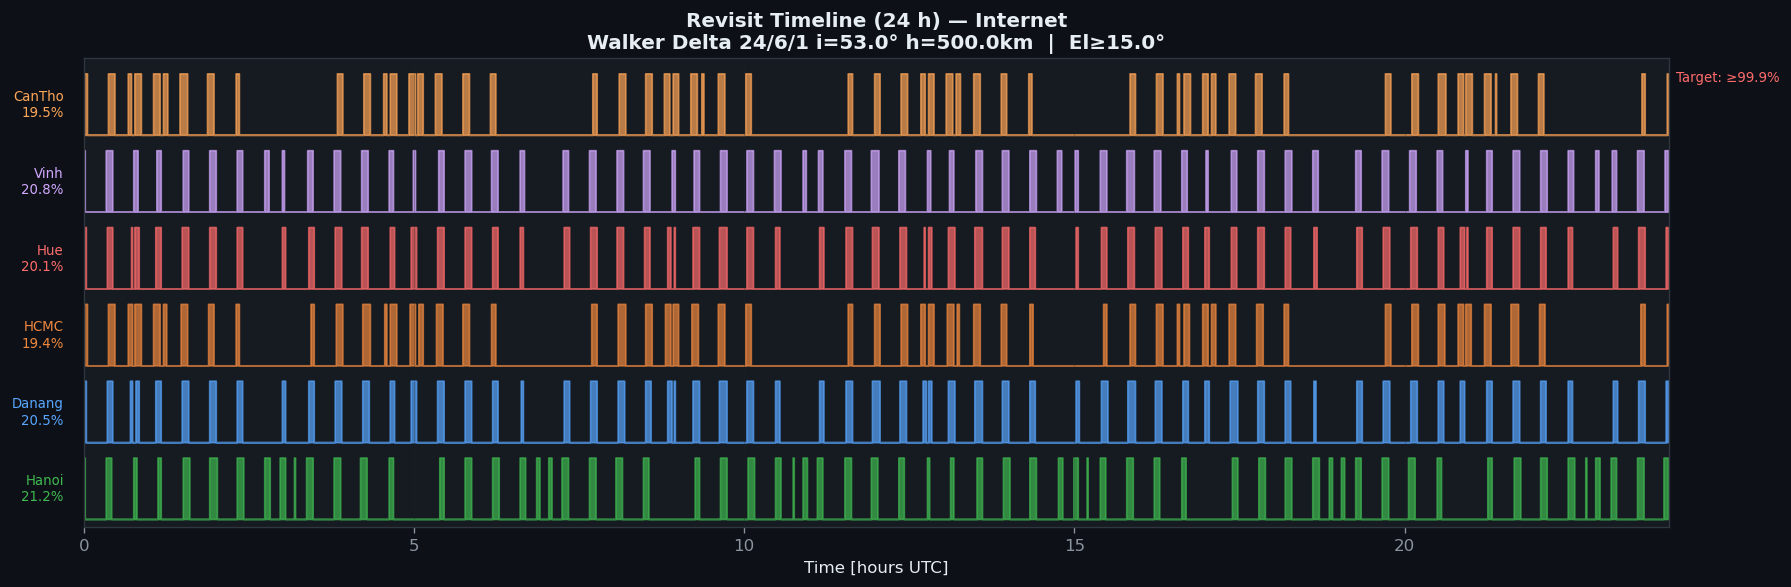

  Coverage per station:
    Hanoi       :  21.25%  ❌
    Danang      :  20.49%  ❌
    HCMC        :  19.38%  ❌
    Hue         :  20.07%  ❌
    Vinh        :  20.76%  ❌
    CanTho      :  19.51%  ❌

WEATHER
  Saved: outputs\simulation\revisit_timeline_weather.png


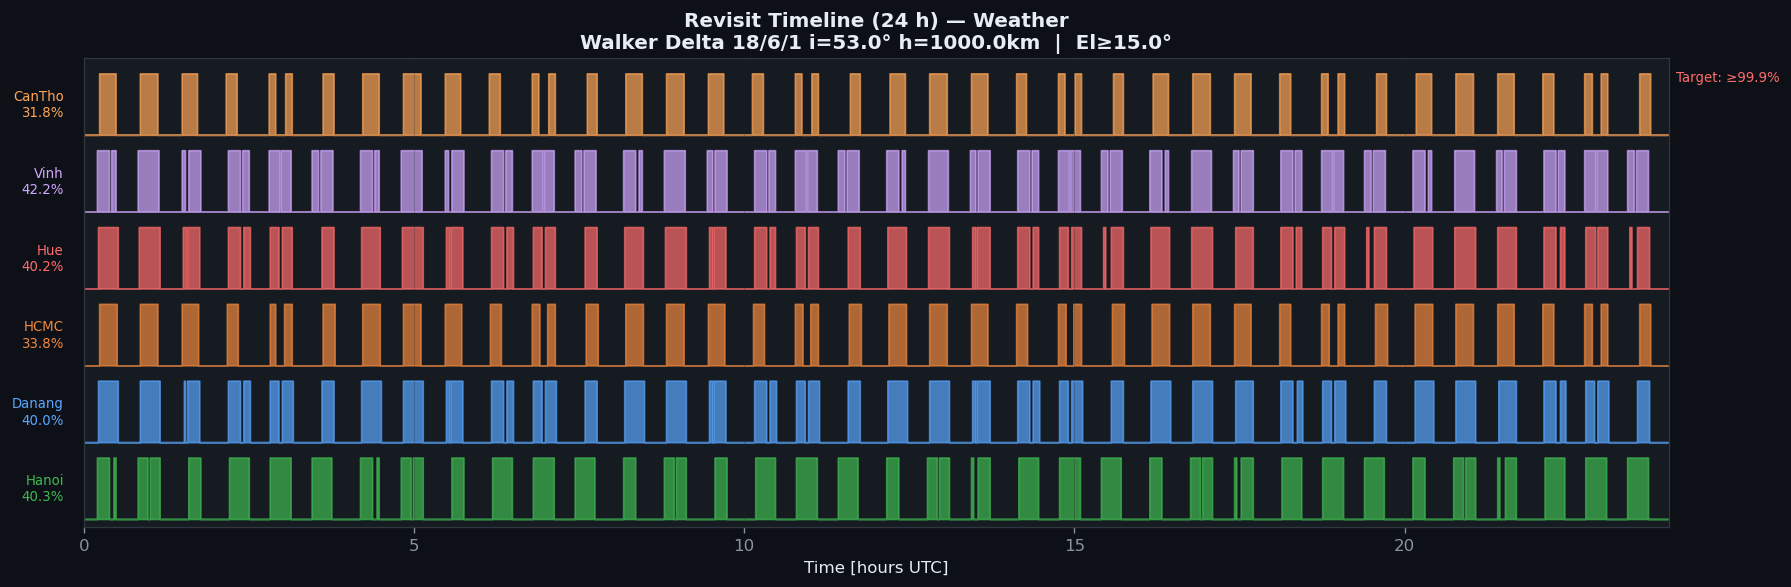

  Coverage per station:
    Hanoi       :  40.28%  ❌
    Danang      :  40.00%  ❌
    HCMC        :  33.82%  ❌
    Hue         :  40.21%  ❌
    Vinh        :  42.22%  ❌
    CanTho      :  31.81%  ❌


In [6]:
def plot_revisit_timeline(constellation: WalkerDelta, service_label: str,
                           el_min_deg: float = 15.0,
                           sim_duration_s: float = 86400.0) -> dict:
    """Show availability timeline (covered vs gap) for all stations."""
    times = np.arange(0, sim_duration_s, 60.0)  # 1-min resolution
    t_hr = times / 3600.0
    h = constellation.altitude_km
    
    station_coverage = {}
    for name, (gs_lat, gs_lon) in VIETNAM_STATIONS.items():
        el_arr = np.zeros(len(times))
        for i, t in enumerate(times):
            positions = walker_delta_positions(constellation, t)
            el_arr[i] = max(
                elevation_angle_deg(lat, lon, h, gs_lat, gs_lon)
                for lat, lon in positions
            )
        station_coverage[name] = (el_arr >= el_min_deg).astype(float)
    
    fig, ax = plt.subplots(figsize=(15, 5))
    station_names = list(station_coverage.keys())
    
    colors = ['#3fb950', '#58a6ff', '#f0883e', '#ff6b6b', '#d2a8ff', '#ffa657']
    for i, (name, cov) in enumerate(station_coverage.items()):
        # Plot as filled bands
        ax.fill_between(t_hr, i + cov * 0.8, i,
                         color=colors[i % len(colors)], alpha=0.7, step='post')
        pct = 100 * np.mean(cov)
        ax.text(-0.3, i + 0.4, f'{name}\n{pct:.1f}%',
                ha='right', va='center', fontsize=8, color=colors[i % len(colors)])
    
    ax.set_xlim(0, sim_duration_s / 3600)
    ax.set_ylim(-0.1, len(station_names))
    ax.set_xlabel('Time [hours UTC]')
    ax.set_title(f'Revisit Timeline (24 h) — {service_label}\n'
                  f'{constellation}  |  El≥{el_min_deg}°',
                  fontweight='bold')
    ax.set_yticks([])
    ax.grid(True, axis='x', alpha=0.3)
    
    # Coverage target line
    target_pct = 99.9
    ax.axhline(0, color='#ff6b6b', linestyle=':', alpha=0)
    ax.text(24.1, len(station_names) - 0.3,
             f'Target: ≥{target_pct}%', color='#ff6b6b', fontsize=8)
    
    plt.tight_layout()
    fname = OUTPUT_DIR / f'revisit_timeline_{service_label.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    print(f'  Saved: {fname}')
    plt.show()
    
    return {name: round(100*np.mean(cov), 3) for name, cov in station_coverage.items()}


print('Running 24-hour revisit timeline (this may take ~1 min)...')
for svc, c in CONSTELLATIONS.items():
    print(f'\n{svc.upper()}')
    results = plot_revisit_timeline(c, service_label=svc.capitalize())
    print('  Coverage per station:')
    for name, pct in results.items():
        status = '✅' if pct >= 99.9 else '⚠️' if pct >= 95 else '❌'
        print(f'    {name:<12}: {pct:6.2f}%  {status}')

## 7. Elevation Angle Time Series & Link Budget

  Saved: outputs\simulation\link_budget_internet.png


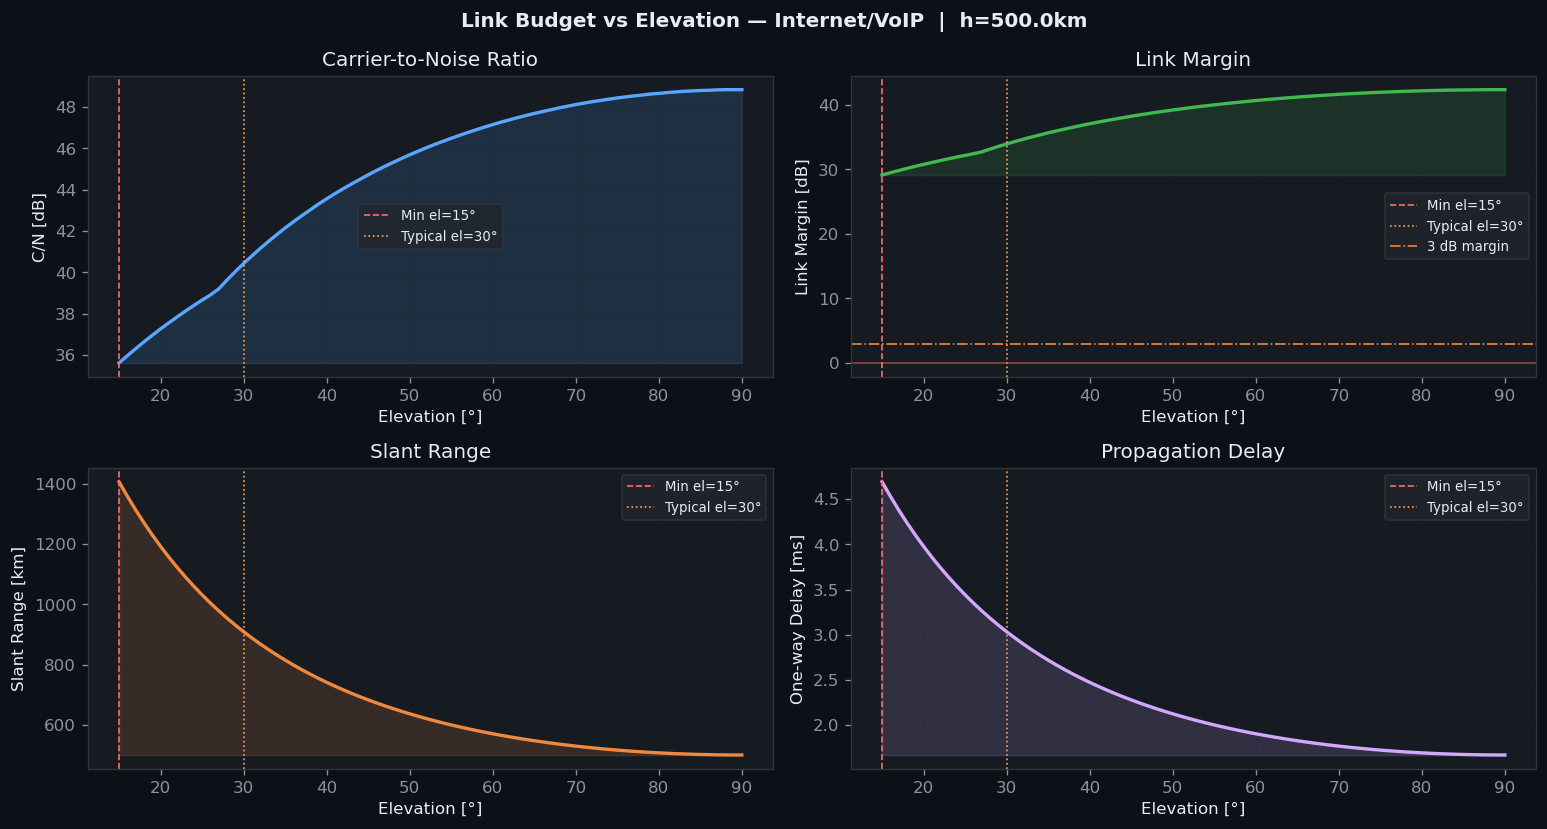

  Saved: outputs\simulation\link_budget_weather.png


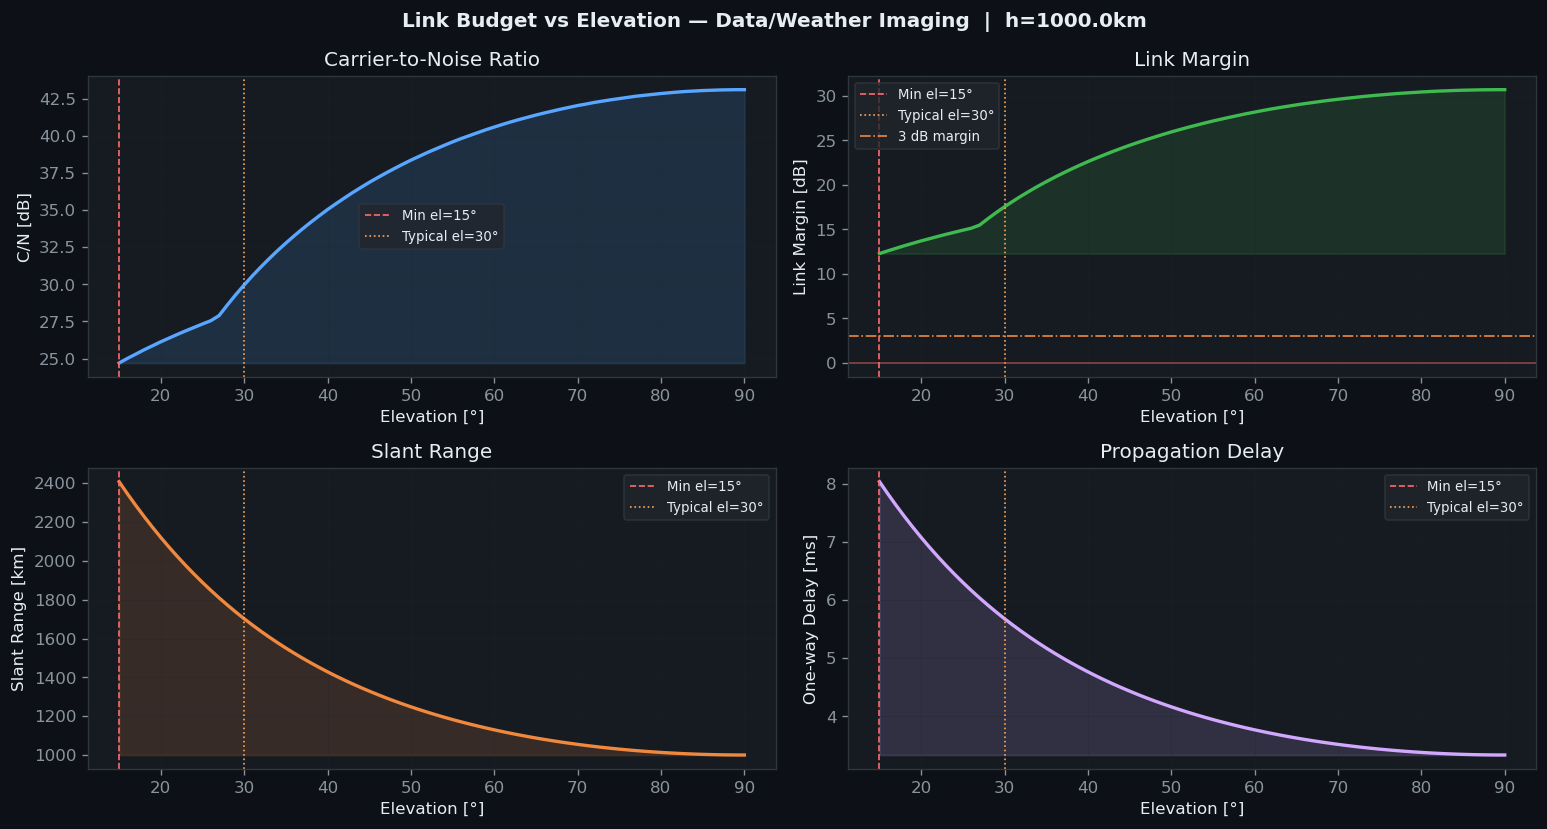

In [7]:
def plot_link_budget_vs_elevation(service_label: str) -> None:
    """Show C/N and link margin as a function of elevation angle."""
    from traffic_model import TrafficModel, INTERNET_VOIP_PROFILE, DATA_WEATHER_PROFILE
    
    profile = INTERNET_VOIP_PROFILE if 'internet' in service_label.lower() else DATA_WEATHER_PROFILE
    elevations = np.arange(15, 91, 1)
    
    cn_list, margin_list, slant_list, delay_list = [], [], [], []
    for el in elevations:
        tm = TrafficModel(profile, elevation_deg=float(el))
        bud = tm.compute_downlink()
        cn_list.append(bud.cn_db)
        margin_list.append(bud.link_margin_db)
        slant_list.append(bud.slant_range_km)
        delay_list.append(bud.slant_range_km / 299792.458 * 1000)
    
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    fig.suptitle(f'Link Budget vs Elevation — {profile.name}  |  h={profile.altitude_km}km',
                  fontweight='bold', fontsize=12)
    
    for ax, y, ylabel, color, title in [
        (axes[0,0], cn_list,     'C/N [dB]',          '#58a6ff', 'Carrier-to-Noise Ratio'),
        (axes[0,1], margin_list, 'Link Margin [dB]',  '#3fb950', 'Link Margin'),
        (axes[1,0], slant_list,  'Slant Range [km]',  '#f0883e', 'Slant Range'),
        (axes[1,1], delay_list,  'One-way Delay [ms]','#d2a8ff', 'Propagation Delay'),
    ]:
        ax.plot(elevations, y, '-', color=color, linewidth=2)
        ax.fill_between(elevations, min(y), y, alpha=0.15, color=color)
        ax.axvline(15, color='#ff6b6b', linestyle='--', linewidth=1, label='Min el=15°')
        ax.axvline(30, color='#ffa657', linestyle=':', linewidth=1, label='Typical el=30°')
        if 'Margin' in ylabel:
            ax.axhline(3, color='#f0883e', linestyle='-.', linewidth=1, label='3 dB margin')
            ax.axhline(0, color='#ff6b6b', linestyle='-', linewidth=1, alpha=0.5)
        ax.set_xlabel('Elevation [°]')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    
    plt.tight_layout()
    fname = OUTPUT_DIR / f'link_budget_{service_label.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    print(f'  Saved: {fname}')
    plt.show()


for svc in CONSTELLATIONS:
    plot_link_budget_vs_elevation(svc)

## 8. Full Coverage Simulation & Export

In [8]:
print('Running full 24-hour coverage simulation...')
print('(Using 60-second timestep — takes ~30-60 seconds)\n')

all_metrics = {}
for svc, c in CONSTELLATIONS.items():
    print(f'=== {svc.upper()} ===')
    analyzer = VietnamCoverageAnalyzer(
        c,
        el_min_deg=15.0,
        sim_duration_s=86400.0,
        time_step_s=60.0,
    )
    metrics = analyzer.run(verbose=True)
    all_metrics[svc] = metrics
    
    # Export
    out_dir = OUTPUT_DIR / svc
    out_dir.mkdir(parents=True, exist_ok=True)
    analyzer.export_json(out_dir / 'coverage_report.json')
    analyzer.export_tle(out_dir / 'vnu_leo.tle')
    
    # Traffic model
    profile = INTERNET_VOIP_PROFILE if svc == 'internet' else DATA_WEATHER_PROFILE
    tm = TrafficModel(profile, elevation_deg=30.0)
    tm.export_json(out_dir / 'traffic_report.json')

Running full 24-hour coverage simulation...
(Using 60-second timestep — takes ~30-60 seconds)

=== INTERNET ===
[VietnamCoverageAnalyzer] Starting simulation
  Constellation : Walker Delta 24/6/1 i=53.0° h=500.0km
  Duration      : 24.0 h  |  Step: 60.0 s  |  Steps: 1440
  Stations      : ['Hanoi', 'Danang', 'HCMC', 'Hue', 'Vinh', 'CanTho']
  Simulation complete in 0.28 s

────────────────────────────────────────────────────────────────────────
  VNU-LEO Coverage Report  —  Walker Delta 24/6/1 i=53.0° h=500.0km
────────────────────────────────────────────────────────────────────────
  Coverage half-angle  : 11.41°
  Footprint radius     : 1269 km
  Overall coverage     : 20.243 %
  Max outage gap       : 5340 s  (89.0 min)
  Mean outage gap      : 1165 s
  Handover interval    : 24.3 min
  Prop delay (el=15°)  : 4.7 ms one-way
  Min RTT              : 9.4 ms

  Station      Coverage %  Max gap (s)  Max El °  Handovers
  ──────────── ────────── ──────────── ───────── ──────────
  Hanoi 

In [9]:
# ── Summary table ──────────────────────────────────────────────────────────
print('\n' + '='*72)
print('  FINAL SUMMARY — VNU-LEO Phase 1 Constellation Analysis')
print('='*72)
print(f'  {"Service":<14} {"N":>4} {"P":>4} {"h km":>6} '
      f'{"Coverage":>10} {"MaxGap(s)":>10} {"RTT(ms)":>8}')
print('  ' + '-'*60)
for svc, m in all_metrics.items():
    c = m.constellation
    status = '✅' if m.coverage_pct >= 99.9 else '⚠️'
    print(f'  {svc:<14} {c.N:>4} {c.P:>4} {c.altitude_km:>6.0f} '
          f'{m.coverage_pct:>9.3f}% {m.max_gap_s:>10.0f} '
          f'{m.round_trip_delay_ms:>8.1f}  {status}')
print('='*72)
print(f'\nAll export files written to: {OUTPUT_DIR.resolve()}')


  FINAL SUMMARY — VNU-LEO Phase 1 Constellation Analysis
  Service           N    P   h km   Coverage  MaxGap(s)  RTT(ms)
  ------------------------------------------------------------
  internet         24    6    500    20.243%       5340      9.4  ⚠️
  weather          18    6   1000    38.056%       1740     16.1  ⚠️

All export files written to: C:\Users\twtvf\OneDrive\Documents\GitHub\BTL-2526II_ELT3098_1\orbit_calc\outputs\simulation
